In [34]:
import pandas as pd
import numpy as np
from skimage import exposure
from hdr_adjustments import hdr_adjustment
import matplotlib.pyplot as plt
import os
from skimage import io
from matplotlib.colors import ListedColormap, BoundaryNorm

In [35]:
AZIMUTH_NORM_SCALE = 360
ZENITH_NORM_SCALE = 135
# Since degree resolution=0.25: 360/0.25=1440
CANVAS_WIDTH = 1440 
CANVAS_HEIGHT = 540


## Initialize Input Paths

In [36]:
# filename = os.path.join('C:/Users/fzhcis/Documents/mylab/tls_demo/demo_files/UMBCBL009_2024-03-28-02-47-26_ALRSET12_060180_000200.800_1830507489.txt')
# filename = os.path.join('C:/Users/fzhcis/Documents/projects/from_RobC/for_Fei/data/palau_2024/AURSET2/UMBCBL009_2024-03-27-23-59-45_AURSET2North_060180_000116.799_1327754030.txt')
filename = os.path.join('C:/Users/fzhcis/Documents/projects/from_RobC/for_Fei/data/palau_2024/NGERURSET2/UMBCBL009_2024-03-25-21-51-30_NGERURSET2North_060180_000225.800_708743674.txt')
saveflag = True

seg_map_path = './cvat/tls-label-cvat-segmentation-mask-2/SegmentationClass/Mean Intensity Image.png'
save_pts_with_colors = False

## Preprocess the Point Cloud data
- read the data as a pandas dataframe
- Clean it
  - Filter with first return and non-extreme intensity values
- prepare x_pix and y_pix columns for grouping

In [37]:
def preprocess_point_cloud(filename: str) -> pd.DataFrame:
    """
    Preprocess a point cloud data file and map scalar field values to pixel coordinates.
    Parameters:
    filename (str): The path to the point cloud data file in CSV format.
    Returns:
    pandas.DataFrame: A DataFrame containing the filtered and processed point cloud data with additional columns for pixel coordinates.
    The input CSV file is expected to have the following columns:
    - 'X': X coordinate of the point.
    - 'Y': Y coordinate of the point.
    - 'Z': Z coordinate of the point.
    - 'zenith': Zenith angle of the point.
    - 'azimuth': Azimuth angle of the point.
    - 'range1metres': Range to the point in meters.
    - 'Intensity': Intensity value of the point.
    - 'Return Number': Return number of the point.
    The function performs the following steps:
    1. Reads the file into a pandas DataFrame.
    2. Filters the DataFrame to include only points with a return number of 1 and intensity between 50 and 1000.
    3. Maps the azimuth and zenith angles to pixel coordinates (x_pix, y_pix) within the bounds of a predefined canvas size.
    4. Ensures the pixel indices are within the bounds of the canvas.
    """
    
    # Step 1: Read the file as a pandas DataFrame
    df = pd.read_csv(
        str(filename),
        delimiter=',', 
        names=['X', 'Y', 'Z', 'zenith', 'azimuth', 'range1metres', 'Intensity', 'Return Number']
    )

    # Step 2: Clean the dataset
    df_filtered = df[
        (df['Return Number'] == 1) &
        (df['Intensity'] >= 50) &
        (df['Intensity'] <= 1000) & 
        (df['range1metres'] >= 0.25)
        
    ]

    # Step 3: Extract scanning angles and map to pixel coordinates
    # Map azimuth (0-360 degrees) to x-coordinate (0 to CANVAS_WIDTH-1)
    df_filtered['x_pix'] = ((df_filtered['azimuth'] / AZIMUTH_NORM_SCALE) * (CANVAS_WIDTH - 1)).astype(int)

    # Map zenith (0-135 degrees) to y-coordinate (0 to CANVAS_HEIGHT-1), flipping the y-axis
    df_filtered['y_pix'] = (((ZENITH_NORM_SCALE - df_filtered['zenith']) / ZENITH_NORM_SCALE) * (CANVAS_HEIGHT - 1)).astype(int)

    # Ensure pixel indices are within bounds
    df_filtered['x_pix'] = df_filtered['x_pix'].clip(0, CANVAS_WIDTH - 1)
    df_filtered['y_pix'] = df_filtered['y_pix'].clip(0, CANVAS_HEIGHT - 1)

    return df_filtered


## Prepare the functions for displaying images.

In [38]:
def display_unwrapped_images(subplot1_image: np.ndarray, 
                             subplot2_image: np.ndarray, 
                             title1: str, 
                             title2: str, 
                             colormap: str = 'plasma', 
                             saveflag: bool = False) -> None:
    """
    Display two images with titles and colorbars.

    Parameters:
    subplot1_image (np.ndarray): The first image to display.
    subplot2_image (np.ndarray): The second image to display.
    title1 (str): Title for the first image.
    title2 (str): Title for the second image.
    colormap (str): Colormap to use for displaying the images. Default is 'plasma'.
    saveflag (bool): If True, save the images to the './outputs/' directory. Default is False.

    Returns:
    None
    """
    fig, axes = plt.subplots(2, 1, figsize=(18, 6))

    # Set the colormap to something more visually friendly
    colormap = colormap  # e.g.: 'jet', 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
    aspect_ratio = CANVAS_HEIGHT / CANVAS_WIDTH

    # Define custom ticks using np.linspace
    y_ticks = np.linspace(0, ZENITH_NORM_SCALE, CANVAS_HEIGHT + 1)
    x_ticks = np.linspace(0, AZIMUTH_NORM_SCALE, CANVAS_WIDTH + 1)

    for ax, subplot_img in zip(axes, [subplot1_image, subplot2_image]):
        im = ax.imshow(subplot_img, cmap=colormap, aspect='auto', extent=[x_ticks[0], x_ticks[-1], y_ticks[0], y_ticks[-1]])
        ax.set_xlabel('Azimuth Angle (degrees)')
        ax.set_ylabel('Zenith from Z (degree)')
        ax.set_xticks(x_ticks[::int(len(x_ticks) / 10)])  # Reduce the number of x-ticks to avoid overlap
        ax.set_yticks(y_ticks[::int(len(y_ticks) / 10)])  # Reduce the number of y-ticks for readability
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust colorbar size

    axes[0].set_title(title1)
    axes[1].set_title(title2)
    plt.tight_layout()
    plt.show()

    if saveflag:
        plt.imsave(f'./outputs/{title1}.png', subplot1_image, cmap=colormap)
        plt.imsave(f'./outputs/{title2}.png', subplot2_image, cmap=colormap)
        fig.savefig(f'./outputs/{title1}_{title2}_combined_image.png')
        print('Images saved to ./outputs/ directory')


### Observe the density map and histograms

In [39]:
def display_density_images(image_data: np.ndarray, saveflag: bool = False) -> None:
    """
    Display a density map image with a discrete colormap and optionally save the image.
    Parameters:
    -----------
    image_data : np.ndarray
        A 2D array representing the density of points per pixel.
    saveflag : bool, optional
        If True, the function will save the displayed image and the raw image data to the './outputs/' directory (default is False).
    Returns:
    --------
    None
    Notes:
    ------
    - The colormap used is 'jet' with the color for zero density set to black.
    - The colorbar is labeled with integer ticks corresponding to the density values.
    - If `saveflag` is True, two images are saved:
        1. 'Point Density Map raw.png' - the raw image data with the 'jet' colormap.
        2. 'Point Density Map.png' - the displayed image with a resolution of 600 dpi.
    """
    # Display the image with the discrete colormap
    fig = plt.figure(figsize=(12, 4))
    max_density = int(image_data.max())

    colors = plt.get_cmap('jet', max_density+1)(np.arange(max_density+1))
    colors[0] = [0, 0, 0, 1]  # Set the color for zero to black (RGBA)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, max_density+1.5, 1), cmap.N)  # Discrete boundaries at each integer
    
    plt.imshow(image_data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(ticks=range(max_density+1))  # Add colorbar with integer ticks
    cbar.set_ticklabels([str(i) for i in range(max_density+1)])  # Set labels to match each value
    cbar.set_label('Points per pixel')
    plt.title('Point Density Map')
    plt.show()

    if saveflag:
        plt.imsave(f'./outputs/Point Density Map raw.png', image_data, cmap=cmap)
        fig.savefig('./outputs/Point Density Map.png', dpi=600)
        print('Images saved to ./outputs/ directory')


In [40]:
def get_density_histogram(image_data: np.ndarray, saveflag: bool = False) -> None:
    """
    Generate and display a histogram of pixel values in the image data.

    Parameters:
    -----------
    image_data : np.ndarray
        A 2D array representing the density of points per pixel.
    saveflag : bool, optional
        If True, the function will save the histogram plot to the './outputs/' directory (default is False).

    Returns:
    --------
    None
    """
    # Flatten the data to get a 1D array of values
    flattened_data = image_data.flatten()

    # Get unique values and their counts
    values, counts = np.unique(flattened_data, return_counts=True)
    normalized_counts = counts / counts.sum()  # Normalize counts to get proportions

    # Create the bar plot
    fig, ax1 = plt.subplots()

    # Absolute count bars
    ax1.bar(values, counts, color='blue', alpha=0.7, label='Absolute Count')
    ax1.set_xlabel('Pixel Value')
    ax1.set_ylabel('Absolute Count', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Add a second y-axis for normalized portion
    ax2 = ax1.twinx()
    ax2.plot(values, normalized_counts, color='orange', marker='o', linestyle='-', label='Normalized Portion')
    ax2.set_ylabel('Normalized Portion', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    # Add grid, legend, and title
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    plt.title('Histogram of Pixel Values in Image Data')
    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

    fig.tight_layout()
    plt.show()
    print(f'Histogram:\nValues: {values}\nCounts: {counts}\nNormalized Counts: {normalized_counts.round(3)}')
    
    if saveflag:
        fig.savefig('./outputs/Point Density Histogram.png', dpi=300)
        print('Histogram saved to ./outputs/ directory')

In [41]:
def unwrap_point_cloud_to_2d_images(filename: str, hdr_method: str = 'clahe', saveflag: bool = True) -> tuple[pd.DataFrame, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel value with different kinds of scalar fields.
    Including density, intensity, range, and range-xy images.

    Parameters:
    filename (str): The path to the point cloud data file in CSV format.
    hdr_method (str): The HDR adjustment hdr_method to apply. Default is 'clahe'.
    saveflag (bool): If True, save the images to the './outputs/' directory. Default is True.

    Returns:
    df_filtered (pd.DataFrame): A DataFrame containing the filtered and processed point cloud data with additional columns for pixel coordinates.
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: A tuple containing the density image, adjusted intensity image, adjusted range image, and adjusted range-xy image.
    """
    # Step 5: Fill in the canvas pixels with scalar field values
    ## Preprocess the point cloud data
    df_filtered = preprocess_point_cloud(filename)
    grouped = df_filtered.groupby(['y_pix', 'x_pix'])

    ## Compute intensity and range per pixel. 
    ## Since less than 0.1% of the pixels contain more than one point, it doesn't matter if we use mean or max.
    group_intensity = grouped['Intensity'].mean()
    group_range = grouped['range1metres'].max()
    pts_per_pixel = grouped.size()
    range_x = grouped['X'].mean()
    range_y = grouped['Y'].mean()
    range_xy = np.sqrt(range_x**2 + range_y**2)

    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    intensity_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_xy_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)  # range in xy plane
    density_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    pxpy_indices = np.array(group_intensity.index.tolist())
    intensity_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_intensity.values
    range_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_range.values
    density_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = pts_per_pixel.values
    range_xy_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = range_xy.values

    # Step 6: Apply HDR adjustment to intensity and range images
    intensity_image_adjusted = hdr_adjustment(intensity_image, method=hdr_method)
    range_image_adjusted = hdr_adjustment(range_image, method=hdr_method)
    range_xy_image_adjusted = hdr_adjustment(range_xy_image, method=hdr_method)
    output_images = (density_image, intensity_image_adjusted, range_image_adjusted, range_xy_image_adjusted)
   
    return df_filtered, output_images


## Run the above process
- display density map and density histogram
- display Intensity Map, Range Map, and Range-XY Map

C:\Users\fzhcis\AppData\Local\Temp\ipykernel_45308\1341423265.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['x_pix'] = ((df_filtered['azimuth'] / AZIMUTH_NORM_SCALE) * (CANVAS_WIDTH - 1)).astype(int)
C:\Users\fzhcis\AppData\Local\Temp\ipykernel_45308\1341423265.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['y_pix'] = (((ZENITH_NORM_SCALE - df_filtered['zenith']) / ZENITH_NORM_SCALE) * (CANVAS_HEIGHT - 1)).astype(int)
C:\Users\fzhcis\AppData\Local\Temp\ipykernel_45308\13

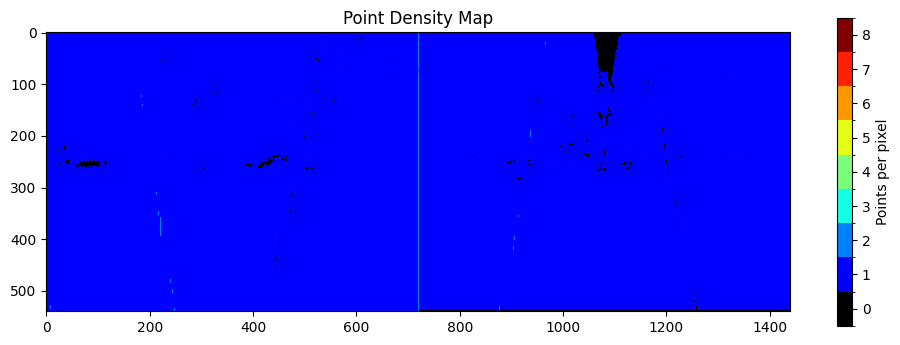

Images saved to ./outputs/ directory


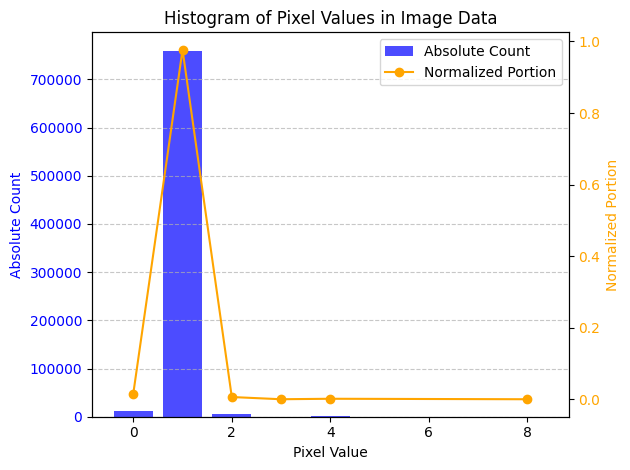

Histogram:
Values: [0. 1. 2. 3. 4. 8.]
Counts: [ 12184 759503   4827     19   1065      2]
Normalized Counts: [0.016 0.977 0.006 0.    0.001 0.   ]
Histogram saved to ./outputs/ directory


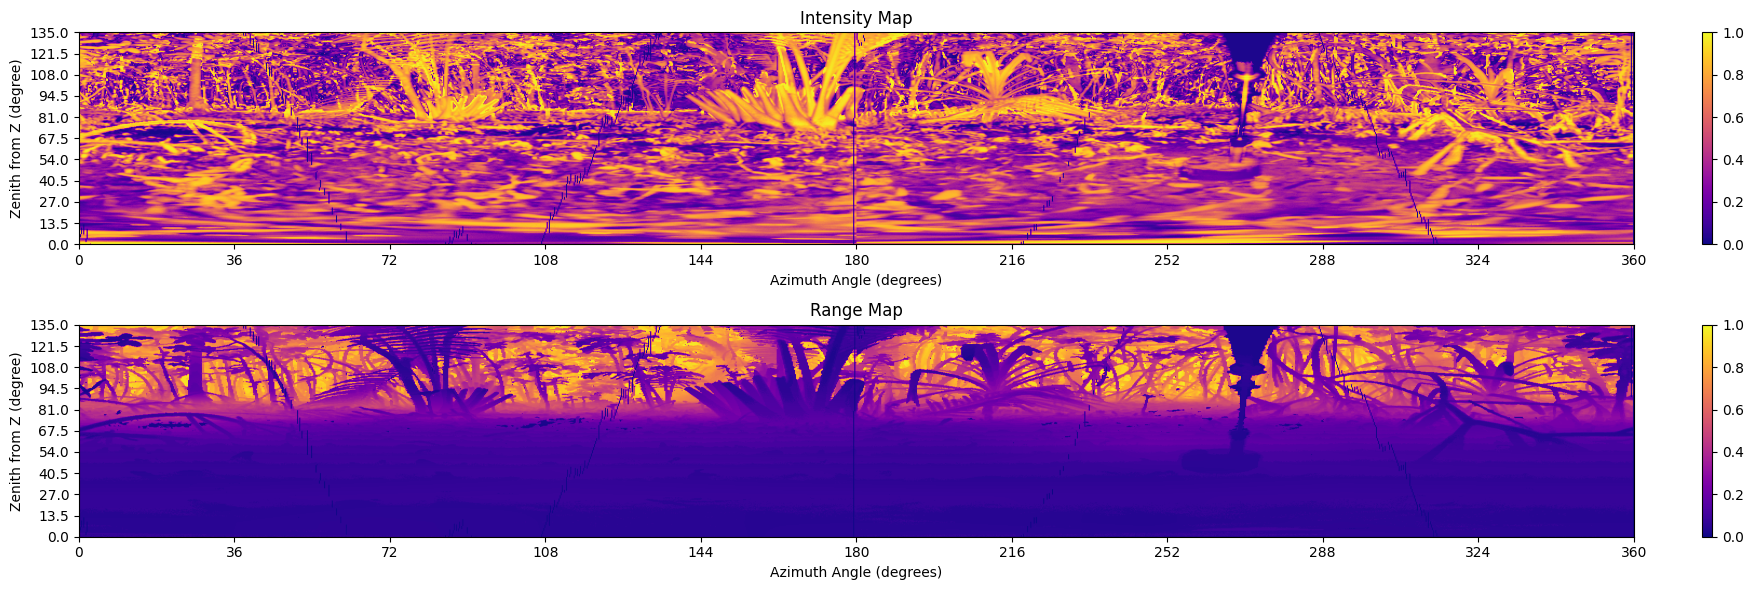

Images saved to ./outputs/ directory


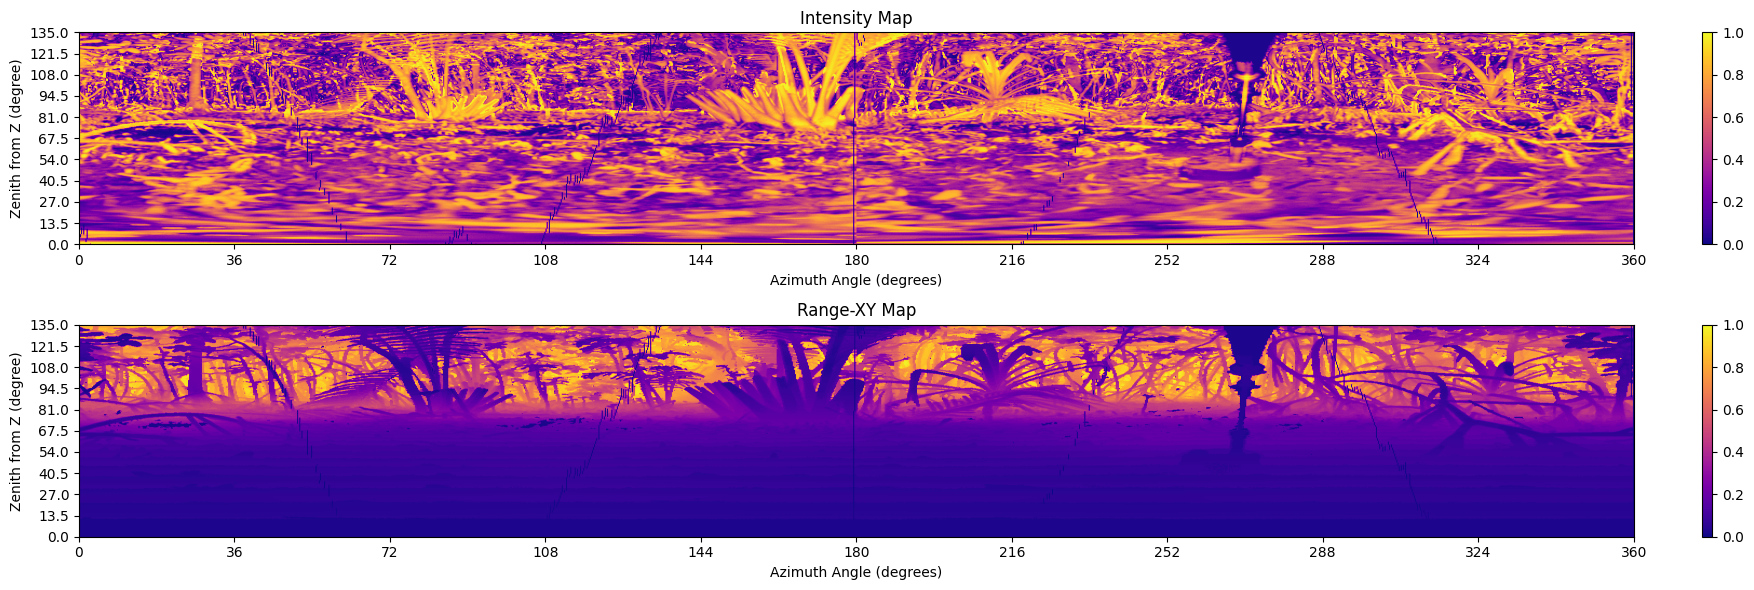

Images saved to ./outputs/ directory


In [42]:
df_filtered, output_images = unwrap_point_cloud_to_2d_images(filename)
density_image, intensity_image_adjusted, range_image_adjusted, range_xy_image_adjusted = output_images

display_density_images(density_image, saveflag=saveflag)
get_density_histogram(image_data=density_image, saveflag=saveflag)

# Step 7: Display and save the adjusted intensity and range images
display_unwrapped_images(intensity_image_adjusted, range_image_adjusted, 
                title1='Intensity Map', title2='Range Map',
                saveflag=saveflag)

display_unwrapped_images(intensity_image_adjusted, range_xy_image_adjusted, 
                title1='Intensity Map', title2='Range-XY Map',
                saveflag=saveflag)


## Attach segmentation bitmap colors to points

In [43]:
def attach_segmentation_colors_to_points(pts_df: pd.DataFrame, seg_map_path: str, output_filename: str) -> pd.DataFrame:
    """
    Attach the color of the pixels in the segmentation map back to the points in the point cloud DataFrame.

    Parameters:
    -----------
    pts_df : pd.DataFrame
        The filtered point cloud DataFrame with pixel coordinates.
    seg_map_path : str
        The path to the segmentation map image file.
    output_filename : str
        The path to save the colorized point cloud data.

    Returns:
    --------
    pd.DataFrame
        The DataFrame with additional columns for RGB values.
    """
    # Step 8: Attach the color of the pixels in the segmentation map back to the points
    ## read the segmented image
    seg_map = io.imread(seg_map_path)  # (height, width, rgb-channels)

    # Create new columns in the DataFrame for RGB values and initialize them
    pts_df.loc[:, 'red'] = np.nan
    pts_df.loc[:, 'green'] = np.nan
    pts_df.loc[:, 'blue'] = np.nan

    # Extract unique pixel coordinates and map their RGB values
    pxpy_indices = pts_df[['y_pix', 'x_pix']].drop_duplicates().values
    rgb_values = seg_map[pxpy_indices[:, 0], pxpy_indices[:, 1]]
    coord_to_rgb = dict(zip(map(tuple, pxpy_indices), rgb_values))

    # Apply RGB values to the DataFrame using a vectorized operation
    coords = pts_df[['y_pix', 'x_pix']].apply(tuple, axis=1)
    rgb_data = coords.map(coord_to_rgb)

    # Assign RGB values to the corresponding columns
    pts_df[['red', 'green', 'blue']] = pd.DataFrame(rgb_data.tolist(), index=pts_df.index)

    # Save the colorized point cloud to a text file
    pts_df.to_csv(output_filename, sep='\t', index=False)
    print(f'Colorized point cloud data saved to {output_filename}!')
    
    return pts_df

# # Example usage
if save_pts_with_colors:
    output_filename = f'./outputs/{os.path.basename(filename)[:-4]}_2d_segmap_labeld.txt'
    pts_df_colored = attach_segmentation_colors_to_points(df_filtered, seg_map_path, output_filename)

## Combine Unwrapped images to an psudo-RGB image

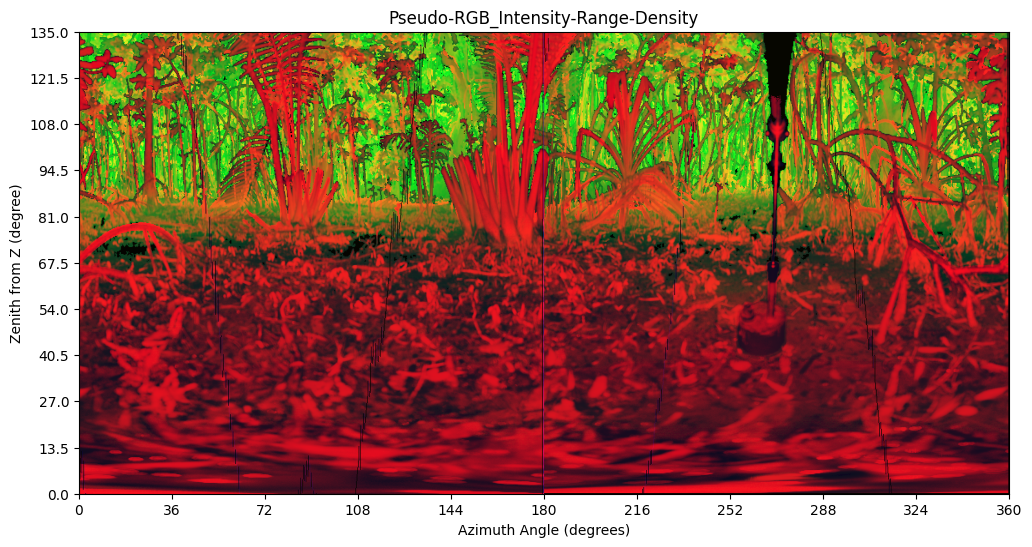

In [44]:
def create_pseudo_rgb_image(intensity_image: np.ndarray, range_image: np.ndarray, density_image: np.ndarray, saveflag:bool=False) -> np.ndarray:
    """
    Combine intensity, range, and density images into a pseudo-RGB image.

    Parameters:
    -----------
    intensity_image : np.ndarray
        The adjusted intensity image.
    range_image : np.ndarray
        The adjusted range image.
    density_image : np.ndarray
        The density image.

    Returns:
    --------
    np.ndarray
        The pseudo-RGB image.
    """
    # Normalize the images to the range [0, 1]
    intensity_norm = (intensity_image - intensity_image.min()) / (intensity_image.max() - intensity_image.min())
    range_norm = (range_image - range_image.min()) / (range_image.max() - range_image.min())
    density_norm = (density_image - density_image.min()) / (density_image.max() - density_image.min())

    # Stack the normalized images to create an RGB image
    # pseudo_rgb_image = np.stack((intensity_norm, range_norm, density_norm), axis=-1)
    pseudo_rgb_image = np.stack((intensity_norm, range_norm, density_norm), axis=-1)

    # Display the pseudo-RGB image
    # Define custom ticks using np.linspace
    y_ticks = np.linspace(0, ZENITH_NORM_SCALE, CANVAS_HEIGHT + 1)
    x_ticks = np.linspace(0, AZIMUTH_NORM_SCALE, CANVAS_WIDTH + 1)
    plt.figure(figsize=(12, 6))
    plt.imshow(pseudo_rgb_image, aspect='auto', extent=[x_ticks[0], x_ticks[-1], y_ticks[0], y_ticks[-1]])
    figure_title = 'Pseudo-RGB_Intensity-Range-Density'
    plt.title(figure_title)
    plt.xticks(x_ticks[::int(len(x_ticks) / 10)])  # Reduce the number of x-ticks to avoid overlap
    plt.yticks(y_ticks[::int(len(y_ticks) / 10)])  # Reduce the number of y-ticks for readability
    plt.xlabel('Azimuth Angle (degrees)')
    plt.ylabel('Zenith from Z (degree)')
    plt.show()

    if saveflag:
        plt.imsave(f'./outputs/{figure_title}.png', pseudo_rgb_image)

    return pseudo_rgb_image

# Create the pseudo-RGB image
pseudo_rgb_image = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, density_image, saveflag=saveflag)

